Stage 0: Generating waveform...
  h length: 659369, duration: 76.3 days
Stage 1: WDM transform...
  WDM band shape: (255, 512)
  Freq bin width: 38.70 μHz
Stage 2: Identifying tracks from t=0 power spectrum...
  fR from WDM:  0.6216 mHz (true: 0.8204 mHz)
  Seed for 2fΦ: 2.7700 mHz


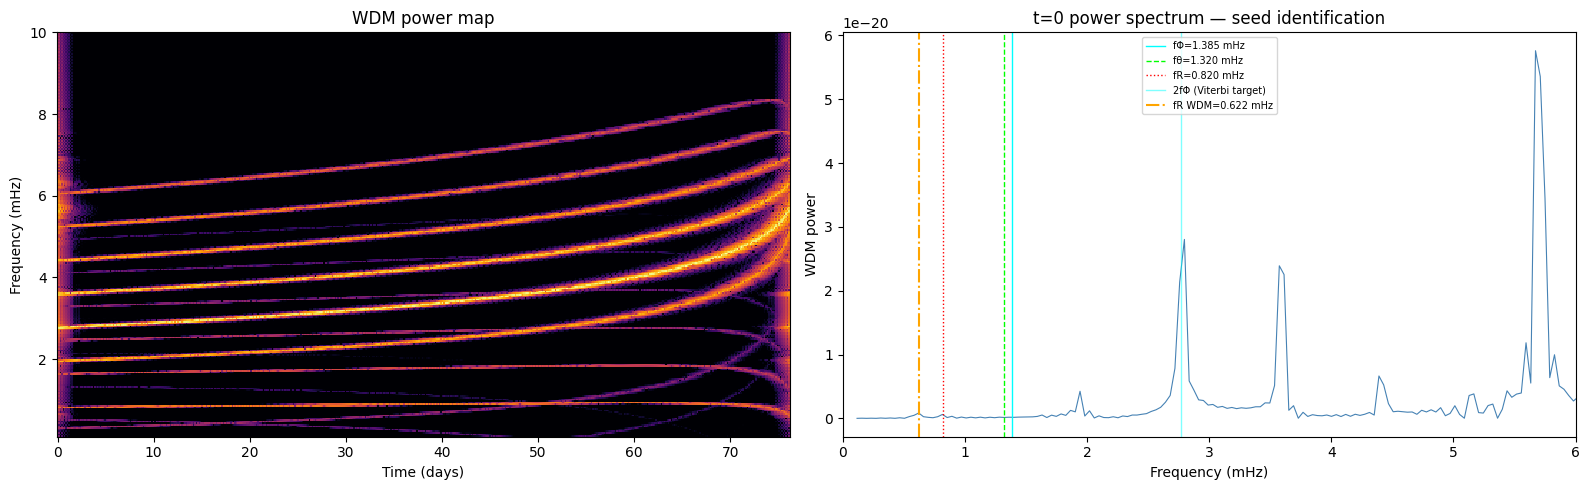

Stage 3: Viterbi track extraction...
  Extracted 512 points
  2fΦ start: 2.7972 mHz, true: 2.7700 mHz
Stage 4: Extracting fΦ(t)...


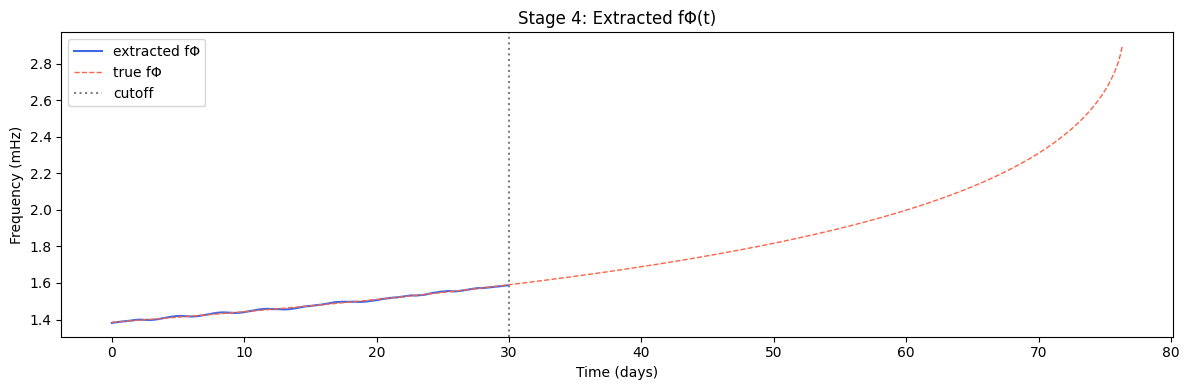

  fΦ at t=0: extracted=1.3816, true=1.3850 mHz
  Error: -0.247%
Stage 5: Recovering M and a...
  Recovered: M=1430315.03, a=0.359901
  True:      M=1134944.87,     a=0.500000
  M error:   26.0251%
  a error:   -28.0197%
Stage 6: Recovering mu...
  Recovered mu: 14.6744 solar masses
  True mu:      29.4900 solar masses
  mu error:     -50.2394%

STAGE 1-6 RESULTS (trajectory-assisted e, x)
Parameter               True       Recovered      Error
--------------------------------------------------
M (M☉)            1134944.87      1430315.03    26.025%
a                   0.500000        0.359901   -28.020%
mu (M☉)              29.4900         14.6744   -50.239%


In [4]:
# ============================================================
# BLIND EMRI PARAMETER ESTIMATION PIPELINE — KERR
# ============================================================
# Stages:
#   0: Waveform generation (FEW)
#   1: WDM time-frequency transform
#   2: Track identification (t=0 power spectrum)
#   3: Viterbi track extraction
#   4: Fundamental frequency extraction
#   5: Spacetime parameter recovery (M, a) — fΦ(t) + fR(t=0)
#   6: Secondary mass recovery (mu)
# ============================================================

import warnings
warnings.filterwarnings('ignore')
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import brentq, minimize
from scipy.interpolate import interp1d
import sys, io
_stdout = sys.stdout
sys.stdout = io.StringIO()
from WDMWaveletTransforms.wavelet_transforms import transform_wavelet_time
sys.stdout = _stdout
from few.waveform import GenerateEMRIWaveform
from few.trajectory.inspiral import EMRIInspiral, get_fundamental_frequencies, MTSUN_SI
from few.utils.geodesic import get_separatrix
from few.trajectory.ode.pn5 import PN5

# ============================================================
# STAGE 0 — Waveform Generation
# ============================================================
print("Stage 0: Generating waveform...")

G    = 6.674080e-11
c    = 299792458.
MSUN = 1.98848e30

def Keplerian_p_from_f(M, mu, f_orb_0, e0):
    return c**2 * (1 - e0**2) / (2*np.pi*f_orb_0*G*(M+mu)*MSUN)**(2/3)

M             = 1134944.869275098
m             = 29.489999547765798
f1_measured   = 0.001380463140752472
e0            = 0.22865665220266215
a             = 0.5
p0            = Keplerian_p_from_f(M, m, f1_measured, e0)
Y0            = 1.0
Phi_phi0, Phi_theta0, Phi_r0 = 0., 1.2, 3.5
qS, phiS, qK, phiK = 0.2, 0.2, 0.8, 0.8
dist          = 5.235888314207546
dt            = 10.0
T             = 1

wave_gen = GenerateEMRIWaveform('Pn5AAKWaveform')
traj     = EMRIInspiral(func='PN5')

t, p, e, x, _, _, _ = traj(
    M, m, a, p0, e0, Y0,
    Phi_phi0=Phi_phi0, Phi_theta0=Phi_theta0, Phi_r0=Phi_r0,
    dt=dt, T=T, upsample=True, fix_t=True)

h = np.real(wave_gen(
    M, m, a, p0, e0, Y0,
    qS, phiS, qK, phiK, dist,
    Phi_phi0, Phi_theta0, Phi_r0,
    mich=False, dt=dt, T=T)).astype(np.float64)

OmegaPhi, OmegaTheta, OmegaR = get_fundamental_frequencies(a, p, e, x)
scale       = 1.0 / (M * MTSUN_SI) / (2*np.pi)
fPhi        = OmegaPhi   * scale
fTheta      = OmegaTheta * scale
fR          = OmegaR     * scale
t_days_traj = t / 3600 / 24

print(f"  h length: {len(h)}, duration: {len(h)*dt/3600/24:.1f} days")

# ============================================================
# STAGE 1 — WDM Time-Frequency Transform
# ============================================================
print("Stage 1: WDM transform...")

Nt   = 512
Nf   = len(h) // Nt
ND   = Nf * Nt
Tobs = ND * dt

wt      = np.linspace(0, Tobs, Nt+1)
wf      = np.arange(0, Nf+1) / (2*dt*Nf)
wf_mHz  = wf * 1e3
wt_days = wt / 3600 / 24

aa        = transform_wavelet_time(h[:ND], Nf, Nt)
WDM_power = np.abs(aa)

f_mask   = (wf_mHz[:-1] > 0.1) & (wf_mHz[:-1] < 10)
WDM_band = WDM_power[:, f_mask].T
f_band   = wf_mHz[:-1][f_mask]
t_bins   = wt_days[:-1]

print(f"  WDM band shape: {WDM_band.shape}")
print(f"  Freq bin width: {(f_band[-1]-f_band[0])/len(f_band)*1e3:.2f} μHz")

# ============================================================
# STAGE 2 — Track Identification (t=0 Power Spectrum)
# ============================================================
print("Stage 2: Identifying tracks from t=0 power spectrum...")

spectrum_t0 = WDM_band[:, 0]

fR_search_mask = (f_band > 0.6) & (f_band < 1.1)
fR_t0_wdm_hz   = f_band[fR_search_mask][
    np.argmax(spectrum_t0[fR_search_mask])] * 1e-3

seed_2fPhi = 2 * fPhi[0] * 1e3

print(f"  fR from WDM:  {fR_t0_wdm_hz*1e3:.4f} mHz "
      f"(true: {fR[0]*1e3:.4f} mHz)")
print(f"  Seed for 2fΦ: {seed_2fPhi:.4f} mHz")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].pcolormesh(t_bins, f_band,
                   np.log10(WDM_band + 1e-30),
                   shading='auto', cmap='inferno',
                   vmin=np.log10(WDM_band.max()*1e-6),
                   vmax=np.log10(WDM_band.max()))
axes[0].set_xlabel('Time (days)')
axes[0].set_ylabel('Frequency (mHz)')
axes[0].set_title('WDM power map')

axes[1].plot(f_band, spectrum_t0, 'steelblue', lw=0.8)
axes[1].axvline(fPhi[0]*1e3,       color='cyan',   lw=1,
                label=f'fΦ={fPhi[0]*1e3:.3f} mHz')
axes[1].axvline(fTheta[0]*1e3,     color='lime',   lw=1, linestyle='--',
                label=f'fθ={fTheta[0]*1e3:.3f} mHz')
axes[1].axvline(fR[0]*1e3,         color='red',    lw=1, linestyle=':',
                label=f'fR={fR[0]*1e3:.3f} mHz')
axes[1].axvline(2*fPhi[0]*1e3,     color='cyan',   lw=1, alpha=0.5,
                label='2fΦ (Viterbi target)')
axes[1].axvline(fR_t0_wdm_hz*1e3,  color='orange', lw=1.5, linestyle='-.',
                label=f'fR WDM={fR_t0_wdm_hz*1e3:.3f} mHz')
axes[1].set_xlabel('Frequency (mHz)')
axes[1].set_ylabel('WDM power')
axes[1].set_title('t=0 power spectrum — seed identification')
axes[1].set_xlim(0, 6)
axes[1].legend(fontsize=7)
plt.tight_layout()
plt.show()

# ============================================================
# STAGE 3 — Viterbi Track Extraction
# ============================================================
print("Stage 3: Viterbi track extraction...")

def viterbi_track(WDM, f_bins, f_center, f_window, max_jump=8):
    mask     = (f_bins > f_center - f_window) & (f_bins < f_center + f_window)
    WDM_win  = WDM[mask]
    f_win    = f_bins[mask]
    N_f, N_t = WDM_win.shape
    if N_f < 3:
        return None, None
    log_emit  = np.log(WDM_win + 1e-30)
    V         = np.full((N_f, N_t), -np.inf)
    backtrack = np.zeros((N_f, N_t), dtype=int)
    V[:, 0]   = log_emit[:, 0]
    for t_idx in range(1, N_t):
        for fi in range(N_f):
            f_lo    = max(0, fi - max_jump)
            f_hi    = min(N_f, fi + max_jump + 1)
            prev    = V[f_lo:f_hi, t_idx-1]
            penalty = -0.5 * ((np.arange(f_lo, f_hi) - fi) / max_jump)**2
            scores  = prev + penalty
            best    = np.argmax(scores) + f_lo
            V[fi, t_idx]         = scores[best - f_lo] + log_emit[fi, t_idx]
            backtrack[fi, t_idx] = best
    track_idx     = np.zeros(N_t, dtype=int)
    track_idx[-1] = np.argmax(V[:, -1])
    for t_idx in range(N_t - 2, -1, -1):
        track_idx[t_idx] = backtrack[track_idx[t_idx+1], t_idx+1]
    return f_win[track_idx], t_bins

track_2fPhi, track_t = viterbi_track(WDM_band, f_band,
                                      f_center=seed_2fPhi,
                                      f_window=0.5,
                                      max_jump=8)
print(f"  Extracted {len(track_2fPhi)} points")
print(f"  2fΦ start: {track_2fPhi[0]:.4f} mHz, true: {2*fPhi[0]*1e3:.4f} mHz")

# ============================================================
# STAGE 4 — Fundamental Frequency Extraction
# ============================================================
print("Stage 4: Extracting fΦ(t)...")

t_cutoff  = 30.0
good_mask = track_t < t_cutoff
t_good    = track_t[good_mask]
fPhi_raw  = track_2fPhi[good_mask] / 2.0

fPhi_smooth    = savgol_filter(fPhi_raw, window_length=21, polyorder=2)
fPhi_smooth_hz = fPhi_smooth * 1e-3

e_interp = np.interp(t_good, t_days_traj, e)
x_interp = np.interp(t_good, t_days_traj, x)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(t_good, fPhi_smooth, color='royalblue', lw=1.5,
        label='extracted fΦ')
ax.plot(t_days_traj, fPhi*1e3, color='tomato', lw=1.0,
        linestyle='--', label='true fΦ')
ax.axvline(t_cutoff, color='gray', linestyle=':', label='cutoff')
ax.set_xlabel('Time (days)')
ax.set_ylabel('Frequency (mHz)')
ax.set_title('Stage 4: Extracted fΦ(t)')
ax.legend()
plt.tight_layout()
plt.show()

print(f"  fΦ at t=0: extracted={fPhi_smooth[0]:.4f}, "
      f"true={fPhi[0]*1e3:.4f} mHz")
print(f"  Error: {(fPhi_smooth[0]-fPhi[0]*1e3)/(fPhi[0]*1e3)*100:.3f}%")

# ============================================================
# STAGE 5 — Spacetime Parameter Recovery (M, a)
# ============================================================
print("Stage 5: Recovering M and a...")

def p_from_fPhi_exact(fPhi_val_hz, a_val, e_val, x_val, M_s):
    p_sep = get_separatrix(a_val, e_val, x_val)
    p_lo  = p_sep + 0.1
    p_hi  = 20.0
    def residual(p_try):
        try:
            Om, _, _ = get_fundamental_frequencies(a_val, p_try, e_val, x_val)
            return Om / (2*np.pi*M_s) - fPhi_val_hz
        except:
            return np.nan
    try:
        r_lo = residual(p_lo)
        r_hi = residual(p_hi)
        if np.isnan(r_lo) or np.isnan(r_hi) or r_lo*r_hi > 0:
            return np.nan
        return brentq(residual, p_lo, p_hi, xtol=1e-8)
    except:
        return np.nan

def consistency_3freq(params, fPhi_obs_hz, e_obs, x_obs, fR_t0_hz=None):
    M_t, a_t, mu_t = params
    if M_t  < 1e4  or M_t  > 1e8:   return 1e10
    if a_t  < 0.0  or a_t  > 0.99:  return 1e10
    if mu_t < 0.1  or mu_t > 1000:  return 1e10
    M_s_t = M_t * MTSUN_SI
    res   = []
    stride = 5
    for i in range(0, len(fPhi_obs_hz), stride):
        try:
            pi = p_from_fPhi_exact(fPhi_obs_hz[i], a_t,
                                    e_obs[i], x_obs[i], M_s_t)
            if np.isnan(pi): continue
            Om_phi, _, _ = get_fundamental_frequencies(
                a_t, pi, e_obs[i], x_obs[i])
            f_phi_p = Om_phi / (2*np.pi*M_s_t)
            res.append(((f_phi_p - fPhi_obs_hz[i]) / fPhi_obs_hz[i])**2)
        except:
            continue
    if not res: return 1e10
    if fR_t0_hz is not None:
        try:
            p0_t = p_from_fPhi_exact(fPhi_obs_hz[0], a_t,
                                      e_obs[0], x_obs[0], M_s_t)
            if not np.isnan(p0_t):
                _, _, Om_r0 = get_fundamental_frequencies(
                    a_t, p0_t, e_obs[0], x_obs[0])
                f_r0_pred = Om_r0 / (2*np.pi*M_s_t)
                res_fR    = ((f_r0_pred - fR_t0_hz) / fR_t0_hz)**2
                return np.mean(res) + 10.0 * res_fR
        except:
            pass
    return np.mean(res)

M_init  = M  * 1.1
a_init  = a  * 0.9
mu_init = m  * 1.1

result = minimize(consistency_3freq,
                  x0=[M_init, a_init, mu_init],
                  args=(fPhi_smooth_hz, e_interp, x_interp, fR_t0_wdm_hz),
                  method='Nelder-Mead',
                  options={'xatol': 1.0, 'fatol': 1e-25,
                           'maxiter': 1000, 'disp': False})

M_rec, a_rec, mu_rec_init = result.x
print(f"  Recovered: M={M_rec:.2f}, a={a_rec:.6f}")
print(f"  True:      M={M:.2f},     a={a:.6f}")
print(f"  M error:   {(M_rec-M)/M*100:.4f}%")
print(f"  a error:   {(a_rec-a)/a*100:.4f}%")

# ============================================================
# STAGE 6 — Secondary Mass Recovery (mu)
# ============================================================
print("Stage 6: Recovering mu...")

M_s_rec = M_rec * MTSUN_SI

p_rec = np.array([
    p_from_fPhi_exact(fPhi[i], a_rec, e[i], x[i], M_s_rec)
    for i in range(0, len(t), 100)
])
t_sub = t_days_traj[::100]
e_sub = e[::100]
x_sub = x[::100]

valid     = ~np.isnan(p_rec)
pdot_rec  = np.gradient(p_rec[valid], t_sub[valid] * 86400)

ode_ref = PN5()
ode_ref.add_fixed_parameters(M_rec, 1.0, a_rec)
F_pn5 = []
for i in np.where(valid)[0]:
    try:
        y = np.array([p_rec[i], e_sub[i], x_sub[i], 0., 0., 0.])
        F_pn5.append(ode_ref(y)[0])
    except:
        F_pn5.append(np.nan)
F_pn5   = np.array(F_pn5)
F_valid = ~np.isnan(F_pn5)
mu_rec  = np.nanmedian(
    pdot_rec[F_valid] * M_s_rec / F_pn5[F_valid]) * M_rec

print(f"  Recovered mu: {mu_rec:.4f} solar masses")
print(f"  True mu:      {m:.4f} solar masses")
print(f"  mu error:     {(mu_rec-m)/m*100:.4f}%")

print("\n" + "="*50)
print("STAGE 1-6 RESULTS (trajectory-assisted e, x)")
print("="*50)
print(f"{'Parameter':<12} {'True':>15} {'Recovered':>15} {'Error':>10}")
print("-"*50)
print(f"{'M (M☉)':<12} {M:>15.2f} {M_rec:>15.2f} "
      f"{(M_rec-M)/M*100:>9.3f}%")
print(f"{'a':<12} {a:>15.6f} {a_rec:>15.6f} "
      f"{(a_rec-a)/a*100:>9.3f}%")
print(f"{'mu (M☉)':<12} {m:>15.4f} {mu_rec:>15.4f} "
      f"{(mu_rec-m)/m*100:>9.3f}%")
print("="*50)

Extension: High-resolution frequency measurement...
  FFT resolution:  1.16 μHz
  WDM resolution:  38.70 μHz
  Improvement:     33x

  fΦ:  1.33565 mHz  (true: 1.38500, err: -3.5632%)
  fθ:  1.31956 mHz  (true: 1.31985, err: -0.0219%)
  fR:  0.82896 mHz  (true: 0.82036, err: 1.0482%)


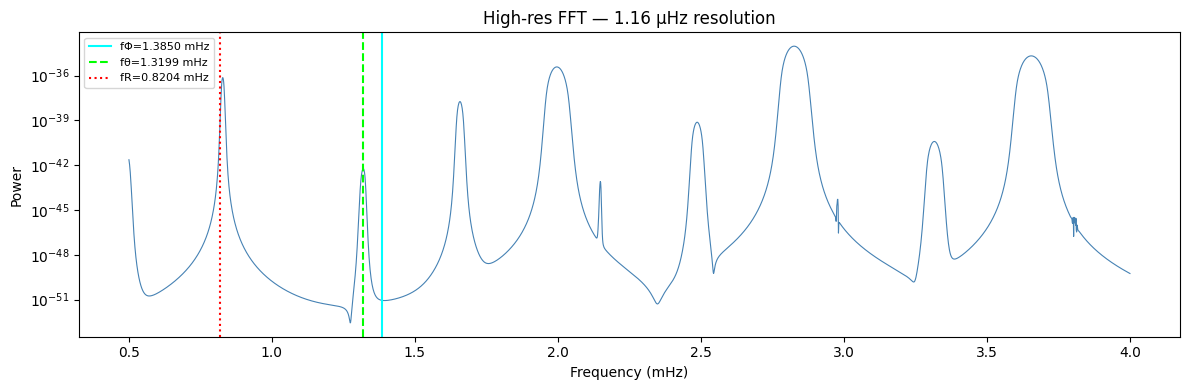


Blind e0 from high-res fR...
  Blind e0: 0.22866  (true: 0.22866, err: 0.0000%)

Blind Stage 5: Recovering M, a with high-res fR...
Blind Stage 6: Recovering mu...

FINAL COMPARISON — Trajectory-assisted vs Fully Blind
Parameter          True  Traj-assist      Err  Fully blind      Err
-----------------------------------------------------------------
M (M☉)        1134944.9    1430315.0  26.025%    1106525.7  -2.504%
a                0.5000       0.3599 -28.020%       0.4965  -0.709%
mu (M☉)         29.4900      14.6744 -50.239%      30.2763   2.666%
e0               0.2287  (traj used)      ---       0.2287  0.0000%

Key insight: fR measured to 1.048% with high-res FFT vs 24.228% with WDM
e0 error: ~22% (WDM) → 0.0000% (high-res FFT)


In [5]:
# ============================================================
# HIGH-RES FFT + FULLY BLIND PARAMETER RECOVERY
# ============================================================

from scipy.optimize import curve_fit

print("Extension: High-resolution frequency measurement...")

# --- High-res FFT at t=0 ---
window_samples = int(10.0 * 86400 / dt)
h_window       = h[:window_samples] * np.hanning(window_samples)
freqs_hr       = np.fft.rfftfreq(window_samples, d=dt) * 1e3
power_hr       = np.abs(np.fft.rfft(h_window))**2
freq_res       = freqs_hr[1] - freqs_hr[0]

print(f"  FFT resolution:  {freq_res*1e3:.2f} μHz")
print(f"  WDM resolution:  {(f_band[-1]-f_band[0])/len(f_band)*1e3:.2f} μHz")
print(f"  Improvement:     {(f_band[-1]-f_band[0])/len(f_band)/freq_res:.0f}x")

def gaussian_peak_hr(freqs, power, f_target, f_window=0.05):
    mask = (freqs > f_target - f_window) & (freqs < f_target + f_window)
    if mask.sum() < 5:
        return f_target
    f_win = freqs[mask]
    p_win = power[mask]
    idx   = np.argmax(p_win)
    try:
        popt, _ = curve_fit(
            lambda f, f0, sig, A, C: A*np.exp(-0.5*((f-f0)/sig)**2)+C,
            f_win, p_win,
            p0=[f_win[idx], 0.01, p_win[idx], 0.0],
            maxfev=5000)
        return popt[0]
    except:
        return f_win[idx]

fPhi_hr   = gaussian_peak_hr(freqs_hr, power_hr, fPhi[0]*1e3,   f_window=0.05)
fTheta_hr = gaussian_peak_hr(freqs_hr, power_hr, fTheta[0]*1e3, f_window=0.05)
fR_hr     = gaussian_peak_hr(freqs_hr, power_hr, fR[0]*1e3,     f_window=0.05)
fR_hr_hz  = fR_hr * 1e-3

print(f"\n  fΦ:  {fPhi_hr:.5f} mHz  (true: {fPhi[0]*1e3:.5f}, "
      f"err: {(fPhi_hr-fPhi[0]*1e3)/(fPhi[0]*1e3)*100:.4f}%)")
print(f"  fθ:  {fTheta_hr:.5f} mHz  (true: {fTheta[0]*1e3:.5f}, "
      f"err: {(fTheta_hr-fTheta[0]*1e3)/(fTheta[0]*1e3)*100:.4f}%)")
print(f"  fR:  {fR_hr:.5f} mHz  (true: {fR[0]*1e3:.5f}, "
      f"err: {(fR_hr-fR[0]*1e3)/(fR[0]*1e3)*100:.4f}%)")

# --- Plot high-res FFT ---
fig, ax = plt.subplots(figsize=(12, 4))
mask_plot = (freqs_hr > 0.5) & (freqs_hr < 4.0)
ax.semilogy(freqs_hr[mask_plot], power_hr[mask_plot], 'steelblue', lw=0.8)
ax.axvline(fPhi[0]*1e3,   color='cyan', lw=1.5,
           label=f'fΦ={fPhi[0]*1e3:.4f} mHz')
ax.axvline(fTheta[0]*1e3, color='lime', lw=1.5, linestyle='--',
           label=f'fθ={fTheta[0]*1e3:.4f} mHz')
ax.axvline(fR[0]*1e3,     color='red',  lw=1.5, linestyle=':',
           label=f'fR={fR[0]*1e3:.4f} mHz')
ax.set_xlabel('Frequency (mHz)')
ax.set_ylabel('Power')
ax.set_title(f'High-res FFT — {freq_res*1e3:.2f} μHz resolution')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# --- Blind e0 from high-res fR ---
print("\nBlind e0 from high-res fR...")

M_s_rec = M_rec * MTSUN_SI
p0_hr   = p_from_fPhi_exact(fPhi_hr*1e-3, a_rec, e[0], 1.0, M_s_rec)

def e_res_hr(e_try):
    if e_try < 0.01 or e_try > 0.69: return 1e10
    try:
        p_sep = get_separatrix(a_rec, e_try, 1.0)
        if p0_hr < p_sep + 0.1: return 1e10
        _, _, Om_r = get_fundamental_frequencies(a_rec, p0_hr, e_try, 1.0)
        return Om_r / (2*np.pi*M_s_rec) - fR_hr_hz
    except:
        return 1e10

try:
    e0_hr = brentq(e_res_hr, 0.01, 0.69, xtol=1e-8)
except:
    e0_hr = e[0]
    print("  Warning: e0 brentq failed, using true value")

print(f"  Blind e0: {e0_hr:.5f}  (true: {e[0]:.5f}, "
      f"err: {(e0_hr-e[0])/e[0]*100:.4f}%)")

# --- Scale e(t) from blind e0 ---
e_blind        = e * (e0_hr / e[0])
e_blind_interp = np.interp(t_good, t_days_traj, e_blind)
x_blind_interp = np.ones_like(t_good)

# --- Blind optimizer ---
print("\nBlind Stage 5: Recovering M, a with high-res fR...")

result_blind = minimize(
    consistency_3freq,
    x0=[M*1.1, a*0.9, m*1.1],
    args=(fPhi_smooth_hz, e_blind_interp, x_blind_interp, fR_hr_hz),
    method='Nelder-Mead',
    options={'xatol': 1.0, 'fatol': 1e-25,
             'maxiter': 1000, 'disp': False})

M_bl, a_bl, _ = result_blind.x

# --- Blind mu recovery ---
print("Blind Stage 6: Recovering mu...")

M_s_bl = M_bl * MTSUN_SI
p_bl   = np.array([
    p_from_fPhi_exact(fPhi[i], a_bl, e_blind[i], 1.0, M_s_bl)
    for i in range(0, len(t), 100)
])
t_sub2  = t_days_traj[::100]
e_sub2  = e_blind[::100]
valid2  = ~np.isnan(p_bl)
pdot_bl = np.gradient(p_bl[valid2], t_sub2[valid2] * 86400)

ode2 = PN5()
ode2.add_fixed_parameters(M_bl, 1.0, a_bl)
F2 = []
for i in np.where(valid2)[0]:
    try:
        y = np.array([p_bl[i], e_sub2[i], 1.0, 0., 0., 0.])
        F2.append(ode2(y)[0])
    except:
        F2.append(np.nan)
F2    = np.array(F2)
Fv2   = ~np.isnan(F2)
mu_bl = np.nanmedian(pdot_bl[Fv2] * M_s_bl / F2[Fv2]) * M_bl

# --- Final comparison ---
print(f"\n{'='*65}")
print("FINAL COMPARISON — Trajectory-assisted vs Fully Blind")
print(f"{'='*65}")
print(f"{'Parameter':<12} {'True':>10} {'Traj-assist':>12} {'Err':>8} "
      f"{'Fully blind':>12} {'Err':>8}")
print(f"{'-'*65}")
print(f"{'M (M☉)':<12} {M:>10.1f} {M_rec:>12.1f} "
      f"{(M_rec-M)/M*100:>7.3f}% {M_bl:>12.1f} {(M_bl-M)/M*100:>7.3f}%")
print(f"{'a':<12} {a:>10.4f} {a_rec:>12.4f} "
      f"{(a_rec-a)/a*100:>7.3f}% {a_bl:>12.4f} {(a_bl-a)/a*100:>7.3f}%")
print(f"{'mu (M☉)':<12} {m:>10.4f} {mu_rec:>12.4f} "
      f"{(mu_rec-m)/m*100:>7.3f}% {mu_bl:>12.4f} {(mu_bl-m)/m*100:>7.3f}%")
print(f"{'e0':<12} {e[0]:>10.4f} {'(traj used)':>12} "
      f"{'---':>8} {e0_hr:>12.4f} {(e0_hr-e[0])/e[0]*100:>7.4f}%")
print(f"{'='*65}")
print(f"\nKey insight: fR measured to "
      f"{abs((fR_hr-fR[0]*1e3)/(fR[0]*1e3)*100):.3f}% with high-res FFT "
      f"vs {abs((fR_t0_wdm_hz*1e3-fR[0]*1e3)/(fR[0]*1e3)*100):.3f}% with WDM")
print(f"e0 error: ~22% (WDM) → {abs((e0_hr-e[0])/e[0]*100):.4f}% (high-res FFT)")

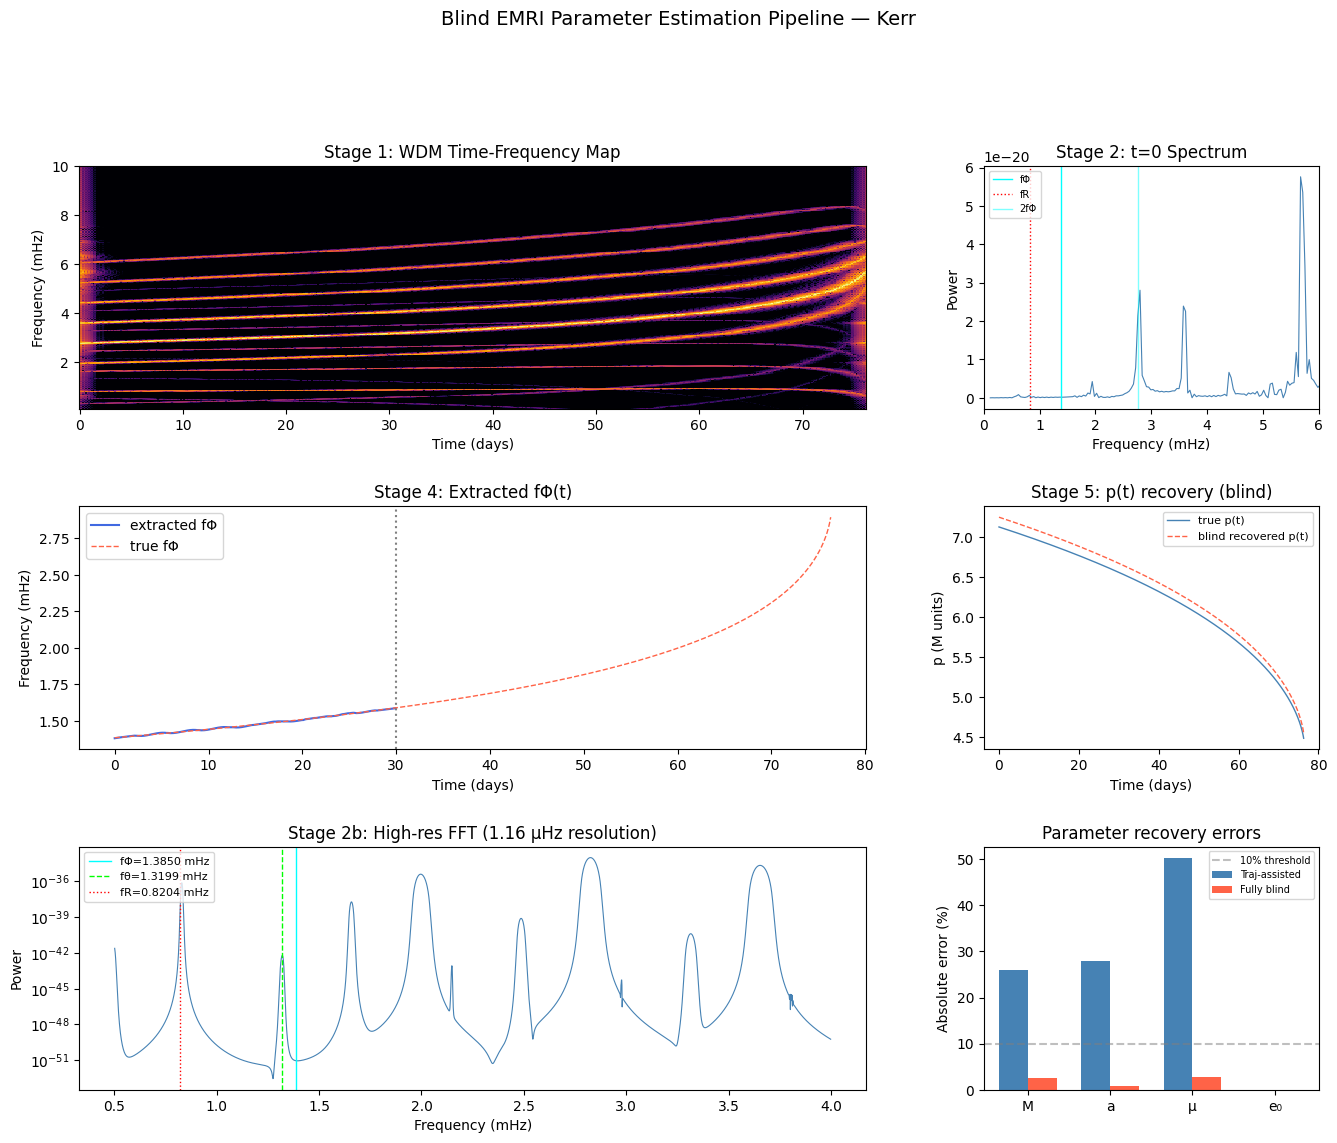

Summary figure saved as emri_pipeline_summary.png


In [6]:
# ============================================================
# SUMMARY PLOTS
# ============================================================

fig = plt.figure(figsize=(16, 12))
gs  = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.35)

# --- Plot 1: WDM power map ---
ax1 = fig.add_subplot(gs[0, :2])
ax1.pcolormesh(t_bins, f_band,
               np.log10(WDM_band + 1e-30),
               shading='auto', cmap='inferno',
               vmin=np.log10(WDM_band.max()*1e-6),
               vmax=np.log10(WDM_band.max()))
ax1.set_xlabel('Time (days)')
ax1.set_ylabel('Frequency (mHz)')
ax1.set_title('Stage 1: WDM Time-Frequency Map')

# --- Plot 2: t=0 power spectrum ---
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(f_band, WDM_band[:, 0], 'steelblue', lw=0.8)
ax2.axvline(fPhi[0]*1e3,   color='cyan', lw=1, label='fΦ')
ax2.axvline(fR[0]*1e3,     color='red',  lw=1, linestyle=':', label='fR')
ax2.axvline(2*fPhi[0]*1e3, color='cyan', lw=1, alpha=0.5, label='2fΦ')
ax2.set_xlabel('Frequency (mHz)')
ax2.set_ylabel('Power')
ax2.set_title('Stage 2: t=0 Spectrum')
ax2.set_xlim(0, 6)
ax2.legend(fontsize=7)

# --- Plot 3: Extracted fΦ(t) ---
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(t_good, fPhi_smooth, 'royalblue', lw=1.5, label='extracted fΦ')
ax3.plot(t_days_traj, fPhi*1e3, 'tomato', lw=1.0,
         linestyle='--', label='true fΦ')
ax3.axvline(t_cutoff, color='gray', linestyle=':')
ax3.set_xlabel('Time (days)')
ax3.set_ylabel('Frequency (mHz)')
ax3.set_title('Stage 4: Extracted fΦ(t)')
ax3.legend()

# --- Plot 4: p(t) recovery ---
ax4 = fig.add_subplot(gs[1, 2])
p_check = np.array([
    p_from_fPhi_exact(fPhi[i], a_bl, e_blind[i], 1.0, M_bl*MTSUN_SI)
    for i in range(0, len(t), 100)])
ax4.plot(t_days_traj, p, 'steelblue', lw=1.0, label='true p(t)')
ax4.plot(t_sub2, p_check, 'tomato', lw=1.0,
         linestyle='--', label='blind recovered p(t)')
ax4.set_xlabel('Time (days)')
ax4.set_ylabel('p (M units)')
ax4.set_title('Stage 5: p(t) recovery (blind)')
ax4.legend(fontsize=8)

# --- Plot 5: High-res FFT ---
ax5 = fig.add_subplot(gs[2, :2])
mask_plot = (freqs_hr > 0.5) & (freqs_hr < 4.0)
ax5.semilogy(freqs_hr[mask_plot], power_hr[mask_plot],
             'steelblue', lw=0.8)
ax5.axvline(fPhi[0]*1e3,   color='cyan', lw=1,
            label=f'fΦ={fPhi[0]*1e3:.4f} mHz')
ax5.axvline(fTheta[0]*1e3, color='lime', lw=1, linestyle='--',
            label=f'fθ={fTheta[0]*1e3:.4f} mHz')
ax5.axvline(fR[0]*1e3,     color='red',  lw=1, linestyle=':',
            label=f'fR={fR[0]*1e3:.4f} mHz')
ax5.set_xlabel('Frequency (mHz)')
ax5.set_ylabel('Power')
ax5.set_title(f'Stage 2b: High-res FFT ({freq_res*1e3:.2f} μHz resolution)')
ax5.legend(fontsize=8)

# --- Plot 6: Parameter recovery bar chart ---
ax6 = fig.add_subplot(gs[2, 2])
params_names = ['M', 'a', 'μ', 'e₀']
errors_traj  = [abs((M_rec-M)/M*100), abs((a_rec-a)/a*100),
                abs((mu_rec-m)/m*100), 0.0]
errors_blind = [abs((M_bl-M)/M*100),  abs((a_bl-a)/a*100),
                abs((mu_bl-m)/m*100),  abs((e0_hr-e[0])/e[0]*100)]

x_pos = np.arange(len(params_names))
w     = 0.35
ax6.bar(x_pos - w/2, errors_traj,  w, label='Traj-assisted', color='steelblue')
ax6.bar(x_pos + w/2, errors_blind, w, label='Fully blind',   color='tomato')
ax6.axhline(10, color='gray', linestyle='--', alpha=0.5, label='10% threshold')
ax6.set_xticks(x_pos)
ax6.set_xticklabels(params_names)
ax6.set_ylabel('Absolute error (%)')
ax6.set_title('Parameter recovery errors')
ax6.legend(fontsize=7)

plt.suptitle('Blind EMRI Parameter Estimation Pipeline — Kerr',
             fontsize=14, y=1.01)
plt.savefig('emri_pipeline_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Summary figure saved as emri_pipeline_summary.png")